## Prithvi Downscaling with ECCC Data: Model Fine-tuning

This notebook is a walk through to use the `Prithvi` downscaling model for fine-tuning using the `ECCC` data

We show how to initalize the model, load the pretrained on MERRA2 weights, and finetune it

In [1]:
!pip install -q h5netcdf matplotlib wget pyyaml xarray scipy torch PrithviWxC granitewxc tqdm

In [2]:
import logging
import warnings
logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
import os
import torch
import wget
from torch.nn.parallel import DistributedDataParallel

from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.utils.eccc_data import get_dataloaders_eccc
from granitewxc.models.model import get_finetune_model_UNET
from granitewxc.utils.plot import plot_sample, plot_loss

Configure the backends and torch states

In [4]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True

It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [5]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    use_gpu=True
else:
    device = torch.device('cpu')

We initialize the Distributed Data Parallel (DDP) environment to leverage multiple GPUs for training

In [6]:
os.environ["LOCAL_RANK"] = "0"
os.environ["RANK"] = "0"
os.environ["WORLD_SIZE"] = "1"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "2468"

local_rank, rank = init_ddp(use_gpu=use_gpu)

### Load Config

We provide a configuration file to define data variables and model parameters

This includes variables to be downscaled, downscaling factor, model's dimensions, paths, ....

In [7]:
config_path = './examples/eccc_downscaling/config_UNET.yaml'
config = get_config(config_path)

## Dataloader 

See `./examples/eccc_downscaling/notebooks/README.md` for instructions about how to download and setup the data

In [8]:
train_dl, val_dl = get_dataloaders_eccc(config)

--> Training batches: 16
--> Validation batches: 16
--> Training samples: 16
--> Validation samples: 16


### Train data

The ECCC data corresponds to the entire Canadian region

For training, we adopt a strategy that randomly crops the data into patches of fixed width and height, which are then used to train the model. For inference we will use the entire region...

You can adjust the size and number of crops in the configuration file

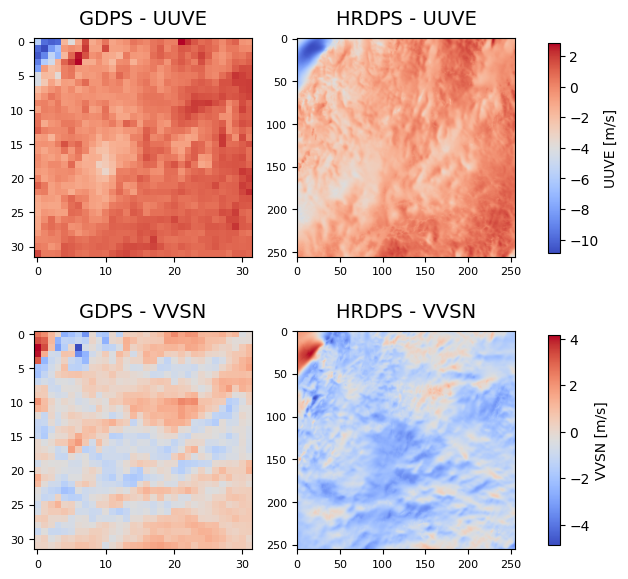

In [9]:
plot_sample(next(iter(train_dl)))

### Model Initialization

The model is built using the loaded configuration. To ensure compatibility with the provided weights during inference, the model configuration should remain consistent with the definitions in the configuration file

We provide **2** different model architectures `UNET` and `CONV` 

Both include:

- **Patch Embedding:** Extracts shallow features from the input data
- **Feature Extraction:** Utilizes the `Prithvi` backbone to extract features.

The key difference between the two is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we are using the UNET version

To switch to the `CONV` model, change the configuration to `config_CONV.yaml` and use the `get_finetune_model(config)` function

In [10]:
model = get_finetune_model_UNET(config)

Creating the model.


--> model has 254,648,712 params.


Let's add the Prithvi-WxC backbone pretrained weights

First download the weights from [Hugging Face](https://huggingface.co/Prithvi-WxC/prithvi.wxc.2300m.v1/tree/main) if you don't have it

In [ ]:
wget.download('https://huggingface.co/Prithvi-WxC/prithvi.wxc.2300m.v1/resolve/main/prithvi.wxc.2300m.v1.pt', out=config.path_backbone_weights)

Load the pretrained backbone

In [12]:
model.load_pretrained_backbone(
    weights_path = config.path_backbone_weights,
    sel_prefix=config.backbone_prefix,
    freeze = config.backbone_freeze,
)
model.to(device)
model = DistributedDataParallel(model, device_ids=[torch.cuda.current_device()], find_unused_parameters=True)

Loading pre-trained model weights ./experiments/pretrained/prithvi.wxc.2300m.v1.pt...


## Finetuning

The model is now ready for training

In [13]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from granitewxc.utils.trainer import train_model
from granitewxc.models.loss import rmse_loss

## 
Defining the optimizer, scaler, and scheduler for the training process.

In [14]:
optimizer = AdamW(model.parameters(), lr=config.learning_rate)
scaler = GradScaler()
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=config.num_epochs * min(len(train_dl), config.limit_steps_train),
    eta_min=config.min_lr,
)
save_every = 4

In this example notebook we are using only 1 data pair for training

Let's train it for a couple epochs (based on the configuration file)

In [15]:
train_losses, val_losses = train_model(
    config, model, train_dl, val_dl, optimizer, scheduler, scaler, local_rank, use_gpu, save_every, rmse_loss
)

Learning rate: 1e-05
Rank 0 starting epoch 1...


Training Epoch 1/5:   0%|                                             | 0/16 [00:00<?, ?batch/s][rank0]:[W402 10:40:56.479875573 reducer.cpp:1400] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())


Validation Epoch: 100%|██████████████████████████████| 16/16 [00:00<00:00, 22.13batch/s, loss=3]


Learning rate: 9.140576474687267e-06
Rank 0 starting epoch 2...


Validation Epoch: 100%|███████████████████████████| 16/16 [00:00<00:00, 25.03batch/s, loss=2.03]


...

Learning rate: 4.109423525312741e-06
Rank 0 starting epoch 4...


Validation Epoch: 100%|███████████████████████████| 16/16 [00:00<00:00, 24.92batch/s, loss=2.01]


Learning rate: 1.8594235253127394e-06
Rank 0 starting epoch 5...


Validation Epoch: 100%|███████████████████████████| 16/16 [00:00<00:00, 23.65batch/s, loss=1.91]


--> saved ./experiments/pretrained/checkpoint_4.pt


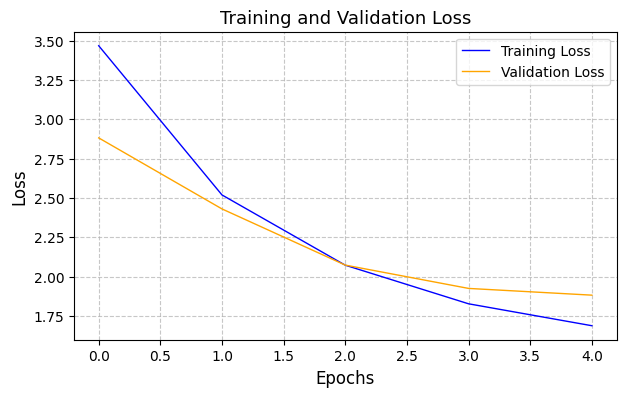

In [16]:
plot_loss(train_losses, val_losses)